# WISDM Human Activity Recognition — data preparation

This notebook turns the raw WISDM accelerometer/gyroscope text files into a
windowed tensor `X` of shape `(n_windows, window_len, 12)` with matching labels `y`
and subject groups `groups`, ready for a subject-wise train/test split.

The 12 channels are the `x, y, z` axes of four streams: `phone/accel`, `phone/gyro`,
`watch/accel`, `watch/gyro`.

### Imports

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn.functional as F
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, f1_score

### Dataset layout and label map

WISDM ships one text file per `(subject, device, sensor)` under
`raw/<device>/<sensor>/data_<id>_<sensor>_<device>.txt`, with rows
`id, activity, timestamp, x, y, z` and a trailing `;` on every line.
Activities are single letters, so `ACTIVITY_MAP` gives them readable names
(note there is no letter `N` in the dataset).

In [2]:
DATA_DIR = Path("data/wisdm-dataset")

RAW_DATA_DIR = DATA_DIR / "raw"

ACTIVITY_MAP = {
    "A": "walking",
    "B": "jogging",
    "C": "stairs",
    "D": "sitting",
    "E": "standing",
    "F": "typing",
    "G": "teeth",
    "H": "soup",
    "I": "chips",
    "J": "pasta",
    "K": "drinking",
    "L": "sandwich",
    "M": "kicking",
    "O": "catch",
    "P": "dribbling",
    "Q": "writing",
    "R": "clapping",
    "S": "folding",
}

ACTIVITIES = list(ACTIVITY_MAP.keys())

DEVICES = (
    "phone",
    "watch",
)
SENSORS = (
    "accel",
    "gyro",
)
COLUMNS = ["id", "activity", "timestamp", "x", "y", "z"]

### Loading the raw files into one typed frame

Three things matter for speed and memory here:

- **Explicit `dtype=`** instead of letting pandas infer. `id` fits in `int16` and the
  axes in `float32`, which keeps the full 15.6M-row frame around ~400 MB. Inferring
  types (or seeding an empty `object` frame and concatenating into it) upcasts the
  float columns to Python objects and costs several GB.
- **Vectorised `;` stripping.** A `converters={"z": ...}` lambda is called once per row,
  i.e. ~15.6M Python calls. Reading `z` as text and calling `.str.rstrip(";")` once
  does the same work in C.
- **One `pd.concat` at the end.** Concatenating inside the loop reallocates and copies
  the whole accumulated frame on every one of the 204 files, which is quadratic.

`activity` / `sensor` / `device` become `category` *after* the concat (per-file
categoricals have different category sets and would be upcast when combined), and
`activity_name` is mapped once on the full frame rather than 204 times.

The processed frame is cached to CSV so the parse only happens once. If you install
`pyarrow`, switching this cache to `.parquet` would shrink it from ~1.2 GB to ~100 MB
and preserve the dtypes, removing the need for the `dtype=` argument on reload.

In [3]:
CACHE_PATH = Path("data/processed/all_data.csv")
RAW_DTYPES = {"id": "int16", "timestamp": "int64", "x": "float32", "y": "float32"}


def load_file_to_frame(file_path: Path, device: str, sensor: str) -> pd.DataFrame:
    df = pd.read_csv(
        file_path, header=None, names=COLUMNS, dtype={**RAW_DTYPES, "z": "str"}
    )
    df["z"] = df["z"].str.rstrip(";").astype("float32")  # drop the trailing ';' in bulk
    df["sensor"], df["device"] = sensor, device
    return df


def load_data() -> pd.DataFrame:
    frames = [
        load_file_to_frame(path, device, sensor)
        for device in DEVICES
        for sensor in SENSORS
        for path in sorted((RAW_DATA_DIR / device / sensor).glob("data_*.txt"))
    ]
    all_df = pd.concat(frames, ignore_index=True)  # one concat, not one per file
    all_df["activity_name"] = all_df["activity"].map(ACTIVITY_MAP)
    return all_df.astype(
        dict.fromkeys(["activity", "activity_name", "sensor", "device"], "category")
    )


CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)

if CACHE_PATH.exists():
    df = pd.read_csv(CACHE_PATH, dtype={**RAW_DTYPES, "z": "float32"}).astype(
        dict.fromkeys(["activity", "activity_name", "sensor", "device"], "category")
    )
else:
    df = load_data()
    df.to_csv(CACHE_PATH, index=False)

### Sanity checks

With real numeric dtypes, `describe()` now reports `mean`/`std`/percentiles for the
axes instead of the `unique`/`top`/`freq` summary you get for object columns.
`memory_usage` is worth a look to confirm the frame is in the hundreds of MB, not GB.

In [4]:
df.head()

,id,activity,timestamp,x,y,z,sensor,device,activity_name
0,1600,A,252207666810782,-0.364761,8.793503,1.055084,accel,phone,walking
1,1600,A,252207717164786,-0.879730,9.768784,1.016998,accel,phone,walking
2,1600,A,252207767518790,2.001495,11.109070,2.619156,accel,phone,walking
3,1600,A,252207817872794,0.450623,12.651642,0.184555,accel,phone,walking
4,1600,A,252207868226798,-2.164352,13.928436,-4.422485,accel,phone,walking


In [5]:
unique_subjects = df["id"].unique().tolist()

print(f"We have {len(unique_subjects)} subjects in the dataset")

We have 51 subjects in the dataset


In [6]:
df.shape

(15630426, 9)

In [7]:
df.describe()

,id,timestamp,x,y,z
count,1.563043e+07,1.563043e+07,1.563043e+07,1.563043e+07,1.563043e+07
mean,1.626267e+03,5.904473e+14,1.291597e-01,-1.607849e+00,5.570484e-01
std,1.478817e+01,6.034457e+14,4.792884e+00,5.025267e+00,3.970900e+00
min,1.600000e+03,2.681027e+11,-7.847761e+01,-7.847761e+01,-7.847761e+01
25%,1.614000e+03,1.079145e+14,-1.423934e+00,-4.157089e+00,-6.402740e-01
50%,1.627000e+03,3.704818e+14,-1.968384e-03,-1.290283e-01,4.527374e-03
75%,1.639000e+03,9.407683e+14,1.293311e+00,1.213215e-01,1.786685e+00
max,1.650000e+03,2.724599e+15,7.847761e+01,6.441166e+01,6.908195e+01


### Class balance per subject

Each subject performs all 18 activities for roughly three minutes, so the bars should be
close to uniform. Anything visibly short here is a subject whose trial will likely be
dropped later by the duration filter.

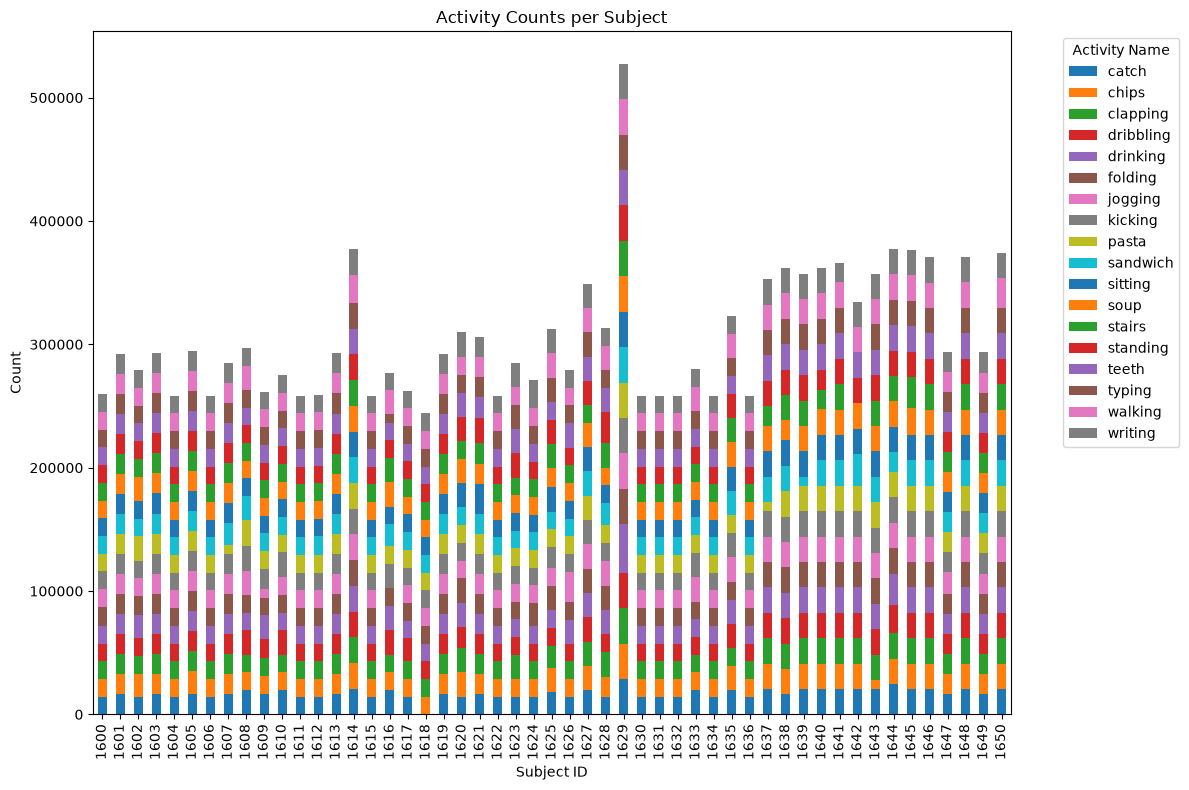

In [8]:
per_subject_activity_counts = (
    df.groupby(["id", "activity_name"], observed=True).size().unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(12, 8))
per_subject_activity_counts.plot(kind="bar", stacked=True, ax=ax)
ax.set_ylabel("Count")
ax.set_xlabel("Subject ID")
ax.set_title("Activity Counts per Subject")
ax.legend(title="Activity Name", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Splitting the recordings into contiguous runs

A model needs fixed-length windows, but the raw files are long recordings. Before
windowing we label each *contiguous* block of rows that shares the same
`(device, sensor, id, activity)` with a `run_id`, so a window can never straddle two
different activities or two different devices.

Sorting by `(device, sensor, id, timestamp)` puts those blocks next to each other, and
`ignore_index=True` renumbers the index in place instead of making a second full copy
the way a chained `.reset_index(drop=True)` does. `run_id` is `int32` — `int64` buys
nothing for a few thousand runs.

In [9]:
df = df.sort_values(
    ["device", "sensor", "id", "timestamp"], kind="stable", ignore_index=True
)

key_cols = ["device", "sensor", "id", "activity"]
df["run_id"] = (
    df[key_cols].ne(df[key_cols].shift()).any(axis=1).cumsum().astype("int32")
)
df.head()

,id,activity,timestamp,x,y,z,sensor,device,activity_name,run_id
0,1600,D,241598622217012,4.059128,5.965424,6.240402,accel,phone,sitting,1
1,1600,D,241598672571016,3.943848,5.636642,6.233505,accel,phone,sitting,1
2,1600,D,241598722925020,3.581696,5.638428,6.787384,accel,phone,sitting,1
3,1600,D,241598773279024,3.441956,5.564392,6.766052,accel,phone,sitting,1
4,1600,D,241598823633028,3.074692,5.422821,6.502975,accel,phone,sitting,1


### Keeping only the runs long enough to window

The sampling parameters live here because the duration filter has to agree with them:
a run shorter than one full window can never produce a sample, so filtering at
`window_sec` (not some other threshold) is what keeps `trials` and the windowing loop
consistent.

`first`/`last` are valid for `t_start`/`t_end` only because the frame is already sorted
by timestamp above. `sort=False` skips re-sorting the group keys we do not need ordered.

In [10]:
target_hz = 20.0  # resample every stream onto this common frequency
window_sec = 10.0  # window size in seconds
stride_sec = 5.0  # hop between consecutive windows, so windows overlap 50%

trials = (
    df.groupby("run_id", observed=True, sort=False)
    .agg(
        id=("id", "first"),
        activity=("activity", "first"),
        t_start=("timestamp", "first"),
        t_end=("timestamp", "last"),
    )
    .reset_index()
)
trials["duration_s"] = (trials["t_end"] - trials["t_start"]) / 1e9
trials = trials[
    trials["duration_s"] >= window_sec
]  # too short to yield a single window

trials.head()

,run_id,id,activity,t_start,t_end,duration_s
0,1,1600,D,241598622217012,241778436383634,179.814167
1,2,1600,E,241892286783982,242072100924919,179.814141
2,3,1600,K,243068040486030,243247904975788,179.864490
3,4,1600,R,243826687535134,244006552032732,179.864498
4,5,1600,S,244326048215533,244505862358216,179.814143


### The `(subject, activity)` trials we will actually window

Deriving the keys from `trials` rather than from `df` does two things: it respects the
duration filter above (otherwise that filter is computed and then silently discarded),
and it scans a few-thousand-row table instead of the full 15.6M-row frame.

In [11]:
trial_keys = trials[["id", "activity"]].drop_duplicates(ignore_index=True)
print(f"{len(trial_keys)} (subject, activity) combinations found")

914 (subject, activity) combinations found


### Resampling, fusing the four streams, and sliding the window

For each `(subject, activity)` trial we take the dominant (longest) run of each of the
four streams, resample it onto a uniform `target_hz` grid with linear interpolation —
the phone and watch sample at different, slightly irregular rates — concatenate the four
`(n, 3)` arrays into one `(n, 12)` array, and slide a `window_len` window across it.

Two optimisations carry this cell:

- **`groupby(...).indices` once, instead of `df.query` per lookup.** The original ran a
  filter over all 15.6M rows for each of the ~3,656 `(trial, device, sensor)` lookups.
  `.indices` builds a dict from stream key to row positions in a single pass, so each
  lookup is a hash. It also fixes a real bug: the f-string query quoted the subject id
  (`id == '1600'`), comparing an integer column against a string, which matched nothing
  and is why this cell used to yield 0 windows.
- **Hot columns pulled out as contiguous NumPy arrays.** `np.interp` wants plain arrays,
  so extracting `timestamp` / `x,y,z` / `run_id` once avoids building a new DataFrame
  slice on every iteration.

`itertuples` replaces `iterrows`, which allocates a Series per row and upcasts mixed
dtypes to `object`. The length guard now compares samples to `window_len`; it previously
compared a sample count against a duration in seconds. A trial is kept only if all four
streams survived, which is what the old `ok` flag was doing.

In [12]:
window_len = int(round(window_sec * target_hz))  # window length in samples
stride_len = int(round(stride_sec * target_hz))  # stride length in samples

ts_all = df["timestamp"].to_numpy()  # pull hot columns out once as contiguous arrays
xyz_all = df[["x", "y", "z"]].to_numpy(dtype=np.float32)
run_all = df["run_id"].to_numpy()
# row positions per (subject, activity, device, sensor), built in a single grouped pass
stream_rows = df.groupby(
    ["id", "activity", "device", "sensor"], observed=True, sort=False
).indices

X_list, y_list, g_list = [], [], []

for subj, activity in trial_keys.itertuples(index=False):
    per_stream_xyz = []
    for device in DEVICES:
        for sensor in SENSORS:
            rows = stream_rows.get((subj, activity, device, sensor))
            if rows is None:  # this subject never recorded this stream
                break
            runs = run_all[rows]
            uniq, counts = np.unique(runs, return_counts=True)
            seg = rows[
                runs == uniq[counts.argmax()]
            ]  # rows of the dominant (longest) run
            t = (
                ts_all[seg] - ts_all[seg[0]]
            ) / 1e9  # ns -> s, already timestamp-sorted
            if t[-1] <= 0:
                break
            t_new = np.linspace(
                0, t[-1], int(t[-1] * target_hz) + 1
            )  # uniform target_hz grid
            arr = np.stack(
                [np.interp(t_new, t, xyz_all[seg, i]) for i in range(3)], axis=1
            )
            if arr.shape[0] < window_len:  # too short for even one window
                break
            per_stream_xyz.append(arr)
    if len(per_stream_xyz) != len(DEVICES) * len(
        SENSORS
    ):  # drop trials missing any stream
        continue
    min_len = min(a.shape[0] for a in per_stream_xyz)  # trim to the shortest stream
    fused = np.concatenate([a[:min_len] for a in per_stream_xyz], axis=1)
    for start in range(0, min_len - window_len + 1, stride_len):
        X_list.append(fused[start : start + window_len])
        y_list.append(activity)
        g_list.append(subj)

In [13]:
print(len(X_list), "windows built")

30629 windows built


### Encoding labels and assembling the arrays

`classes` is sorted so the label indices are stable across runs — important if you save a
checkpoint and later want to read the class names back off it.

`np.asarray(X_list, dtype=np.float32)` allocates the final array directly.
`np.stack(...).astype(np.float32)` would first materialise a `float64` array (because
`np.interp` returns `float64`) and then copy it down, briefly using twice the memory.

`groups` holds the subject id per window; pass it to `GroupShuffleSplit` so no subject
appears in both train and test, otherwise overlapping windows from the same person leak
across the split and the score is meaningless.

In [14]:
classes = sorted(set(y_list))
class_to_idx = {c: i for i, c in enumerate(classes)}

In [15]:
X = np.asarray(X_list, dtype=np.float32)

In [16]:
y = np.array([class_to_idx[c] for c in y_list], dtype=np.int64)
groups = np.array(g_list, dtype=np.int64)

In [17]:
print("X:", X.shape, " y:", y.shape, " groups:", groups.shape)

X: (30629, 200, 12)  y: (30629,)  groups: (30629,)
